<h4 style="font-size: 30px;"><strong>Fig3:Monthly temporal scale considering the ENSO</strong></h4>

<h4 style="font-size: 20px;"><strong>ENSO</strong></h4>

In [1]:
import pandas as pd
import numpy as np
from glob import glob

hourly_input = '../DATA/rainfall/hourly_gauges_SIATA_EPM/'
daily_output = '../DATA/rainfall/daily_gauges_SIATA_EPM/'
monthly_output = '../DATA/rainfall/monthly_gauges_SIATA_EPM/'
annual_output = '../DATA/rainfall/annual_gauges_SIATA_EPM/'
path_ENSO = '../DATA/rainfall/ENSO/'
path_inventory = '../DATA/landslides/'
output_figures = '../FIGURES/'


enso_df = pd.read_excel(f'{path_ENSO}ONI.xlsx', index_col=0)
enso_df=enso_df.loc[1972:2017]
enso_df.columns=np.arange(1,13)
ENSO_values=(np.array(enso_df).ravel())
ENSO_dates=pd.date_range('1972-01-01','2017-12-31', freq='M')
ENSO_df=pd.DataFrame({'ENSO':ENSO_values}, index=ENSO_dates)
ENSO_df['ID_ENSO']=np.where(ENSO_df>=0.5,1,np.where(ENSO_df<=-0.5,-1,0))

<h4 style="font-size: 20px;"><strong>Rainfall</strong></h4>

In [2]:
monthly_files = sorted(glob(monthly_output + 'Monthly_Est_*.csv'))
stations_with_paths = [(int(file.split('_')[-1].split('.')[0]), file) for file in monthly_files]

stations_with_paths_sorted = sorted(stations_with_paths, key=lambda x: x[0])
monthly_files = [station[1] for station in stations_with_paths_sorted]

all_stations_df = pd.DataFrame()

#Solo con las estaciones de EPM
for file in monthly_files[-16:]:
    station_data = pd.read_csv(file, index_col='Fecha', parse_dates=True)
    all_stations_df = pd.concat([all_stations_df, station_data], axis=1)

all_stations_df = all_stations_df[(all_stations_df.index >= '1972-01-01') & (all_stations_df.index <= '2017-12-31')]

monthly_rainfall_df = all_stations_df.groupby([ENSO_df['ID_ENSO'], all_stations_df.index.month]).mean()

<h4 style="font-size: 20px;"><strong>Landslides</strong></h4>

In [3]:
landslides_df = pd.read_csv(f'{path_inventory}inventory_GEOHAZARDS_20240824.csv')
landslides_df['Fecha'] = pd.to_datetime(landslides_df['Fecha'], errors='coerce')

landslides_df = landslides_df[(landslides_df['Fecha'] >= '1972-01-01') & (landslides_df['Fecha'] <= '2017-12-31')]
landslides_series = landslides_df.resample('M', on='Fecha').size()
landslides_series = landslides_series.reset_index(name='Count')  

landslides_series['Year'] = landslides_series['Fecha'].dt.year
landslides_series['Month'] = landslides_series['Fecha'].dt.month

landslides_series = landslides_series.set_index('Fecha').join(ENSO_df['ID_ENSO'], how='left')

monthly_landslides_df = landslides_series.groupby(['ID_ENSO', landslides_series.index.month])['Count'].sum().unstack().fillna(0)

<h4 style="font-size: 20px;"><strong>ENSO: Rainfall + Landslides</strong></h4>

In [4]:
# Separar los datos por fases ENSO
rainfall_nina = monthly_rainfall_df.loc[-1]
rainfall_nino = monthly_rainfall_df.loc[1]
rainfall_neutro = monthly_rainfall_df.loc[0]

landslides_nina = monthly_landslides_df.loc[-1]
landslides_nino = monthly_landslides_df.loc[1]
landslides_neutro = monthly_landslides_df.loc[0]

<h4 style="font-size: 20px;"><strong>Graphics</strong></h4>

In [5]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cmap = cm.get_cmap('coolwarm')

left_rgb   = cmap(0.0)   # extremo izquierdo  (La Niña-súper)
center_rgb = cmap(0.5)   # punto medio        (Neutro)
right_rgb  = cmap(1.0)   # extremo derecho    (El Niño-súper)

# 3) Conviértelos a código hexadecimal (más práctico para gráficas)
left_hex   = mcolors.rgb2hex(left_rgb)
center_hex = mcolors.rgb2hex(center_rgb)
right_hex  = mcolors.rgb2hex(right_rgb)

print("Izquierda :", left_hex)
print("Centro    :", center_hex)
print("Derecha   :", right_hex)

Izquierda : #3b4cc0
Centro    : #dddcdc
Derecha   : #b40426


/tmp/ipykernel_3395665/2273496315.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')


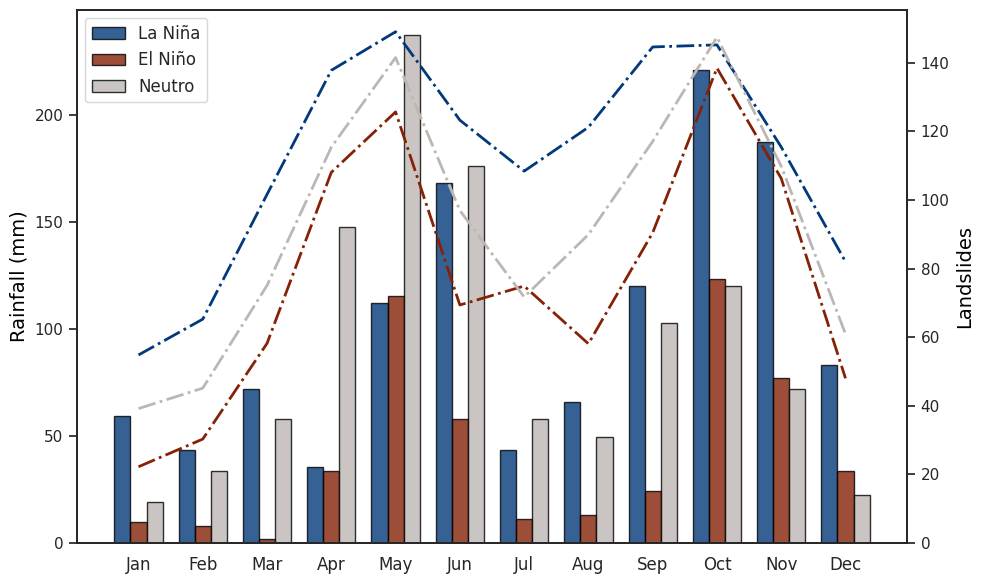

In [6]:
import cmcrameri.cm as cm
import seaborn as sns
import matplotlib.pyplot as plt

# Colores coherentes con el heat-map
# color_nina   = '#3b4cc0'
# color_neutro = '#dddcdc'
# color_nino   = '#b40426'
color_nina   = cm.vik(0.1)
color_neutro = cm.vik(0.5)
color_neutro =  tuple(np.array(color_neutro[:3]) * 0.8) + (color_neutro[3],)
color_nino   = cm.vik(0.9)

colors = [color_nina, color_nino, color_neutro]   


sns.set(style="white", color_codes=False)

x = np.arange(1, 13)
Months_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Colores específicos (azul, rojo y gris)
#colors = ['blue', 'red', 'gray']

sns.lineplot(x=x, y=rainfall_nina.mean(axis=1), ax=ax1, color=colors[0], linestyle='-.', lw=2)
sns.lineplot(x=x, y=rainfall_nino.mean(axis=1), ax=ax1, color=colors[1], linestyle='-.', lw=2)
sns.lineplot(x=x, y=rainfall_neutro.mean(axis=1), ax=ax1, color=colors[2], linestyle='-.', lw=2)

w = 0.25
ax2.bar(x + w * -1, landslides_nina.values, width=w, color=colors[0], alpha=0.8, label='La Niña', edgecolor='black', linewidth=1)
ax2.bar(x + w * 0, landslides_nino.values, width=w, color=colors[1], alpha=0.8, label='El Niño', edgecolor='black', linewidth=1)
ax2.bar(x + w * 1, landslides_neutro.values, width=w, color=colors[2], alpha=0.8, label='Neutro', edgecolor='black', linewidth=1)

ax1.set_xticks(x)
ax1.set_xticklabels(Months_names, fontsize=12)
ax1.set_ylim(0)
ax1.set_ylabel('Rainfall (mm)', color='k', fontsize=14)
ax2.set_ylabel('Landslides', color='k', fontsize=14)

ax1.grid(False)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

# Leyenda combinada
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax2.legend(lines, labels, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig(f'{output_figures}fig03.png', bbox_inches = "tight", dpi=300)